# Plot and animate data as view from above

In [ ]:
import sys
is_notebook = True if 'ipykernel' in sys.argv[0] else False

if is_notebook:
    %matplotlib inline
    #%matplotlib widget


### start command for python script
`  jupyter nbconvert --to script 01-Plume-Tracking-in-3D-Data.ipynb && { python3 01-Plume-Tracking-in-3D-Data.py 1 23 3 ; } ;  `   


In [ ]:
import sys, os, glob
import pylab as plt
import json
import numpy as np
import pandas as pd
import xarray as xr
xr.set_options(keep_attrs=True)
import datetime
import utilities
from utilities import fetch_3d_data, convert_units_3d, track_plume, fetch_meteogram_data
from utilities import update_dataset_metadata, plot_3d_col_wrap, new_fjet2, convert_units_meteogram
from utilities import logscale_FacetGrid, define_bin_boundaries, set_name_tick_params

from utilities.init_common import init_analysis
from utilities.holimo_helpers import ( load_and_prepare_holimo, 
                                    interpolate_timeseries, 
                                    rebin_timeseries )
import matplotlib.colors as colors
import colormaps as pcmaps
import importlib
from dask.diagnostics.progress import ProgressBar
# ============================================================================
# PATHS & CONFIG
# ============================================================================
holimo_file      = '/work/bb1262/user/schimmel/cloudlab_data/holimo/2023-01-25/CL_20230125_1000_1140_SM058_SM060_ts1.nc'

# model_data_path  = '/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_200x160x100/ensemble_output/cs-eriswil__20251209_001346/'
# extpar_file      = '/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_200x160x100/COS_in/extPar_Eriswil_200x160.nc'

# model_data_path  = '/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_50x42x100/ensemble_output/cs-eriswil__20251125_114053/'
# # model_data_path  = '/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_50x42x100/ensemble_output/cs-eriswil__20251129_230943/'
# extpar_file      = '/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_50x42x100/COS_in/extPar_Eriswil_50x40.nc'


model_data_root  = '/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/'
#default
# cs_run, ep_dom = "cs-eriswil__20251215_205448", "200x160" # 200x160
# cs_run, ep_dom = "cs-eriswil__20251209_001346", "200x160" # 200x160
# cs_run, ep_dom  = "cs-eriswil__20251129_230943", "50x40" # 50x40
# cs_run, ep_dom  = "cs-eriswil__20251125_114053", "50x40" # 50x4
cs_run, ep_dom  = "cs-eriswil__20260210_113944", "50x40" # 50x40

if not is_notebook and len(sys.argv)>2:
    cs_run = sys.argv[1]
    ep_dom = sys.argv[2]

model_data_path = model_data_root + f'/RUN_ERISWILL_{ep_dom}x100/ensemble_output/{cs_run}/'
extpar_file     = model_data_root + f'/RUN_ERISWILL_{ep_dom}x100/COS_in/extPar_Eriswil_{ep_dom}.nc'



# fetch 3d file list and extract datestring to find flare meteograms
flist_3d         = sorted(glob.glob(model_data_path + '3D_??????????????.nc'))


print("\n[1] INPUT_ORG namelist file")
with open(glob.glob(model_data_path + "*.json")[0], "r") as jsonfile: 
    meta = json.load(jsonfile)
#
#
exp_names        = [f.split('/')[-1].split('_')[-1].split('.')[0] for f in flist_3d]
cs_run            = model_data_path.split('/')[-2]
lflare_runs       = [meta[exp]['INPUT_ORG']['sbm_par']['lflare'] for exp in exp_names]
flare_exp_name    = [exp for exp in exp_names if meta[exp]['INPUT_ORG']['sbm_par']['lflare']][0]
flare_exp_nc_file = [f for f in flist_3d if flare_exp_name in f][0]
flare_org_nml     = meta[flare_exp_name]['INPUT_ORG']
print('flare run :     ', flare_exp_name, '  flare emissions =    ', meta[flare_exp_name]['INPUT_ORG']['flare_sbm']['flare_emission'])

# Setup plot configuration dict
cfg = {
    'flare_exp_name': flare_exp_name,
    'flare_exp_nc_file': flare_exp_nc_file,
    'resolution': '400m' if '50x40' in meta[flare_exp_name]['domain'] else '100m',
    'resolution_deg': 0.004 if '50x40' in meta[flare_exp_name]['domain'] else 0.001,
    'ydate_ini': str(meta[flare_exp_name]['INPUT_ORG']['runctl']['ydate_ini']),
    'hstart': str(meta[flare_exp_name]['INPUT_ORG']['runctl']['hstart']),
    'hstop': str(meta[flare_exp_name]['INPUT_ORG']['runctl']['hstop']),
    'dpi': 300,
    'pixel_size': (1920, 1080),
    'png_path': './',
    'poolsize': 128,
    'flare_lat': 47.07425,
    'flare_lon': 7.90522,
    'lflare': meta[flare_exp_name]['INPUT_ORG']['sbm_par']['lflare'],
    'flare_emissions': meta[flare_exp_name]['INPUT_ORG']['flare_sbm']['flare_emission'],
    'flare_dn': meta[flare_exp_name]['INPUT_ORG']['flare_sbm']['flare_dn'],
    'ishape': meta[flare_exp_name]['INPUT_ORG']['sbm_par']['ishape'],
    'iimfr': meta[flare_exp_name]['INPUT_ORG']['sbm_par']['iimfr'],
    'origin_lat': 47.070522,
    'origin_lon': 7.872991,
    'plot_xlim': (7.7671843, 7.94),
    'plot_ylim': (47.02, 47.12),
    'delta_x': 163.3876495361328,
    'delta_y': 111.1947021484375,
    'delta_t': 10.0,
    'n_lon': 186,
    'n_lat': 146,
    'n_time': 191,
    'n_alt': 20,
    'vel_lims': [-0.5, 0.5],
    'v_lims_qi': [0.0001, 1.0],
    'tick_size': 8,
    'axis_size': 9.5,
    'timer_size': 16.5,
    
}

ds_3d = fetch_3d_data(flare_exp_nc_file, extpar_file, meta[flare_exp_name]['INPUT_ORG'], var_sets=['meteo', 'spec'], chunks={'time': 4})
ds_3d = update_dataset_metadata(ds_3d)
ds_3d = convert_units_3d(ds_3d, ds_3d["rho"])
print("\n[2] Fetching 3D data ... done")
print("\n " + " "*10 + "Number of 3D files: ", len(flist_3d))

reduced_domain = dict(latitude=slice(None,  cfg['flare_lat'] + 2.*cfg['resolution_deg']), 
                      longitude=slice(None, cfg['flare_lon'] + 2.*cfg['resolution_deg']) )
ds_3d = ds_3d.isel(altitude=slice(80, None))
ds_3d = ds_3d.sel(reduced_domain)


[1] INPUT_ORG namelist file
flare run :      20260210113944   flare emissions =     1000000.0

[2] Fetching 3D data ... done

           Number of 3D files:  4


In [4]:

meteo_flist = sorted(glob.glob(model_data_path + f'M_??_??_{flare_exp_name}.nc'))
if len(meteo_flist)>0:
    ds_meteo = fetch_meteogram_data(meteo_flist)
    for i in range(len(ds_meteo)):
        ds_meteo[i] = update_dataset_metadata(ds_meteo[i])
        ds_meteo[i] = convert_units_meteogram(ds_meteo[i], ds_meteo[i]['RHO'])
        ds_meteo[i] = ds_meteo[i].isel(altitude=slice(80, None))
    
    print("\n[3] Fetching Meteogram data ... done")
    print("\n " + " "*10  + "Number of meteogram files: ", len(meteo_flist))
    print("Number of meteogram files: ", len(meteo_flist))



[3] Fetching Meteogram data ... done

           Number of meteogram files:  3
Number of meteogram files:  3



[4] Fetching HOLIMO data ... done


In [6]:

    # FORTRAN NAMELIST INPUT_DIA list of meteograms for 50x40x100
    # stationlist_tot =   0,    0,  47.0695,  7.8730,  '48_01_20251129231107',
    #                     0,    0,  47.0745,  7.9009,  '83_01_20251129231107',
#coors_ew   = [47.0695,  7.8730]
coors_ew   = [47.0676,  7.8726]
coors_seed = [47.0745,  7.9009]
vcoords = np.array([coors_ew, coors_seed]).T

In [7]:
# load 3d data into memory, same location as meteograms
with ProgressBar() as pbar:
    mod = ds_3d[['qi', 'qfw', 'qw', 'dz', 't']]
    mod = mod.sel( latitude=vcoords[0, :], longitude=vcoords[1, :], method='nearest' )
    mod = xr.where( mod < 1e-7, np.nan, mod ).persist()



[########################################] | 100% Completed | 94.08 s


In [7]:
# load meteogram data into memory
if len(meteo_flist)>0:
    with ProgressBar() as pbar:
        for m in ds_meteo:
            m = m[ ['QI', 'QFW'] ].isel( altitude = slice(80, None) )
            m = xr.where( m < 1e-7, np.nan, m )
            m = m.persist()



[########################################] | 100% Completed | 16.98 s
[########################################] | 100% Completed | 14.76 s


In [8]:
ds_3d

<xarray.Dataset> Size: 39GB
Dimensions:      (time: 191, altitude: 100, latitude: 26, longitude: 36,
                  diameter: 66)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2023-01-25T09:28:20 ... 2023-01-25...
  * altitude     (altitude) float64 800B 2.2e+04 2.15e+04 ... 822.0 812.8
  * latitude     (latitude) float32 104B 47.02 47.02 47.03 ... 47.11 47.11 47.12
  * longitude    (longitude) float32 144B 7.767 7.773 7.779 ... 7.967 7.973
  * diameter     (diameter) float64 528B 0.00226 0.002847 ... 7.523e+03
    latitude2D   (latitude, longitude) float32 4kB 47.02 47.02 ... 47.12 47.12
    longitude2D  (latitude, longitude) float32 4kB 7.767 7.773 ... 7.967 7.973
    altitude3D   (altitude, latitude, longitude) float64 749kB dask.array<chunksize=(100, 26, 36), meta=np.ndarray>
Data variables: (12/13)
    hhl          (time, altitude, latitude, longitude) float64 143MB dask.array<chunksize=(4, 100, 26, 36), meta=np.ndarray>
    rho          (time, altitude, latitude, longitude) float64 143MB dask.array<chunksize=(4, 100, 26, 36), meta=np.ndarray>
    qi           (time, altitude, latitude, longitude) float64 143MB dask.array<chunksize=(4, 100, 26, 36), meta=np.ndarray>
    qc           (time, altitude, latitude, longitude) float64 143MB dask.array<chunksize=(4, 100, 26, 36), meta=np.ndarray>
    qs           (time, altitude, latitude, longitude) float64 143MB dask.array<chunksize=(4, 100, 26, 36), meta=np.ndarray>
    qv           (time, altitude, latitude, longitude) float64 143MB dask.array<chunksize=(4, 100, 26, 36), meta=np.ndarray>
    ...           ...
    dz           (time, altitude, latitude, longitude) float64 143MB dask.array<chunksize=(4, 100, 26, 36), meta=np.ndarray>
    t            (time, altitude, latitude, longitude) float64 143MB dask.array<chunksize=(4, 100, 26, 36), meta=np.ndarray>
    nf           (time, altitude, latitude, longitude, diameter) float64 9GB dask.array<chunksize=(4, 100, 26, 36, 66), meta=np.ndarray>
    nw           (time, altitude, latitude, longitude, diameter) float64 9GB dask.array<chunksize=(4, 100, 26, 36, 66), meta=np.ndarray>
    qw           (time, altitude, latitude, longitude, diameter) float64 9GB dask.array<chunksize=(4, 100, 26, 36, 66), meta=np.ndarray>
    qfw          (time, altitude, latitude, longitude, diameter) float64 9GB dask.array<chunksize=(4, 100, 26, 36, 66), meta=np.ndarray>
Attributes:
    ncfile:   /work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs//...
    run_id:   20251129231107

### 

In [9]:
VAR_LIST = [
    'U', 
    'V',       
    'W',     
    'T',     
    'QV',      
    'QC',       
    'QI',           
    'TKE',           
    'RHO',            
    'PHL',             
    'PML',              
    'T2m', 
    'NI', 
    'QIA', 
    'NINP', 
    'QV_Sp', 
    'QC_Sp', 
    'QI_Sp', 
]
def cspecs_statistics(ds, name, var_list=None):
    lvar = ds.data_vars if var_list is None else var_list
        
    print(f'{name} VARIABLES')
    print('-'*95)
    print(f'\n{"variable":22s} {"min":12s} {"max":12s} {"mean":12s} {"std":10s} {"shape":11s} -- {"unit":12s}')
    print('-'*95)
    for var in lvar:
        units = ds[var].attrs.get("units", ds[var].attrs.get("unit", "N/A"))
        print(f'{var:20s} {ds[var].min().values:12.4f} {ds[var].max().values:12.4f} {ds[var].mean().values:12.4f} {ds[var].std().values:12.4f} {"("+", ".join(str(s) for s in ds[var].values.shape)+")":10s}  /  ({units})')


cspecs_statistics(ds_hd, "\nHOLIMO")
cspecs_statistics(mod, "\nC-SPECS (3D)")


if len(meteo_flist)>0:
    for i in range(len(ds_meteo)):
        cspecs_statistics(ds_meteo[i], f"\nC-SPECS MET({i})", var_list=VAR_LIST)

print('-'*95)
print(f'boundaries (liquid spectrum):   hist_min_size = {lbb[0]:.2f} µm    -to-   water_max_size = {lbb[1]:.2f} µm')
print(f'boundaries (frozen spectrum): ice_lowest_size = {cbb[0]:.2f} µm   -to-    hist_max_size = {cbb[1]:.2f} µm')




HOLIMO VARIABLES
-----------------------------------------------------------------------------------------------

variable               min          max          mean         std        shape       -- unit        
-----------------------------------------------------------------------------------------------
Water_concentration        0.0085     725.5873     396.3909     116.5782 (5743)      /  (cm-3)
Ice_concentration          0.0060       2.1418       0.2120       0.3112 (5743)      /  (cm-3)
Water_meanD                6.7928      35.1329       9.7704       0.6756 (5743)      /  (µm)
Ice_meanD                 35.1329     274.6065     142.4251      31.0408 (5743)      /  (µm)
Water_content              0.0000       0.3303       0.2212       0.0624 (5743)      /  (g*m-3)
Ice_content                0.0003       1.7267       0.2977       0.3477 (5743)      /  (g*m-3)
Water_PSDnoNorm            0.0038     279.1887      35.0606      47.1969 (5743, 40)  /  (cm-3)
Ice_PSDnoNorm            

In [10]:
def plot_ts_spectra(ds_model, ds_holimo, title='', height_window=(1350, 1100), time_window=None, xlim=None):    
    
    time_window_holimo = (np.datetime64('2023-01-25T10:35:00'), np.datetime64('2023-01-25T10:45:00'))

    if '20251129_230943' in cs_run:
        time_window = (np.datetime64('2023-01-25T09:35:00'), np.datetime64('2023-01-25T09:45:00')) if time_window is None else time_window  # default
        xlim = (np.datetime64('2023-01-25T09:30:00'), np.datetime64('2023-01-25T10:00:00')) if xlim is None else xlim  # default  

    else:    
        time_window = (np.datetime64('2023-01-25T12:35:00'), np.datetime64('2023-01-25T12:45:00')) if time_window is None else time_window
        xlim = (np.datetime64('2023-01-25T12:30:00'), np.datetime64('2023-01-25T13:00:00'))if xlim is None else xlim
            
    delta_t_mod = float(np.diff(ds_model.time.values)[0]) * 1e-9 # in seconds
    delta_t_hol = float(np.diff(ds_holimo.time.values)[0]) * 1e-9 # in seconds
    timeheigt_kw = dict( x='time',     ylim=(800, 1600), cmap=new_fjet2 )
    timespec_kw  = dict( y='diameter', ylim=(1, 400), yscale='log', cmap=new_fjet2 )
    spec_kw      = dict( x='diameter', xlim=(1, 400), ylim=(1e-2, 1e2), xscale='log', yscale='log' )
    
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 3.5))
    
    with ProgressBar() as pbar:
        ds_model.sum('diameter').plot( ax=ax[0], **timeheigt_kw )
        ds_model.sel( altitude=slice(*height_window), time=slice(*time_window) ).sum('altitude').plot( ax = ax[1], **timespec_kw)
        (delta_t_mod*ds_model).sel( altitude=slice(*height_window), time=slice(*time_window) ).sum(['altitude', 'time']).plot.step( ax = ax[2], label='CSPECS', **spec_kw)
        (delta_t_hol*ds_holimo).sel( time=slice(*time_window_holimo) ).sum('time').plot.step(ax = ax[2], label='HOLIMO', **spec_kw)
    
    for j in range(2):
        ax[j].set_xlim(*xlim)
        ax[0].vlines(time_window[j], *height_window, colors='red', linestyles='dashed', linewidth=0.95, alpha=0.65)
        ax[0].hlines(height_window[j], *time_window, colors='red', linestyles='dashed', linewidth=0.95, alpha=0.65)
    
    for iax in ax.flatten():
        set_name_tick_params(iax)
        iax.set_title('')
    ax[0].set_ylabel(f'altitude / (m)')
    ax[1].set_ylabel(f'diameter / (µm)')
    ax[2].set_ylabel(f'$dN_i/d\log(D_p)$ / (cm$^{{-3}}$ log(μm$^{{-1}}$))')
    ax[-1].legend(loc='upper left')
    
    fig.suptitle(title, y=1.03, fontsize=20)
    fig.subplots_adjust(left=0, right=1, top=0.9, bottom=0, hspace=0.01, wspace=0.45)
    return fig, ax



In [11]:
print(f"cs_run = {cs_run}")
if '20251129_230943' in cs_run:
    tw = (np.datetime64('2023-01-25T09:35:00'), np.datetime64('2023-01-25T09:45:00'))
else:
    tw = (np.datetime64('2023-01-25T12:35:00'), np.datetime64('2023-01-25T12:45:00'))

cs_run = cs-eriswil__20260210_113944


[                                        ] | 0% Completed | 265.66 us

[########################################] | 100% Completed | 12.68 s
[########################################] | 100% Completed | 4.73 ss
[########################################] | 100% Completed | 4.33 ss
[########################################] | 100% Completed | 102.83 ms
[########################################] | 100% Completed | 101.84 ms
[########################################] | 100% Completed | 102.16 ms


/home/b/b382237/.conda/envs/pcpaper_env/lib/python3.11/site-packages/xarray/plot/utils.py:813: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale(yscale)


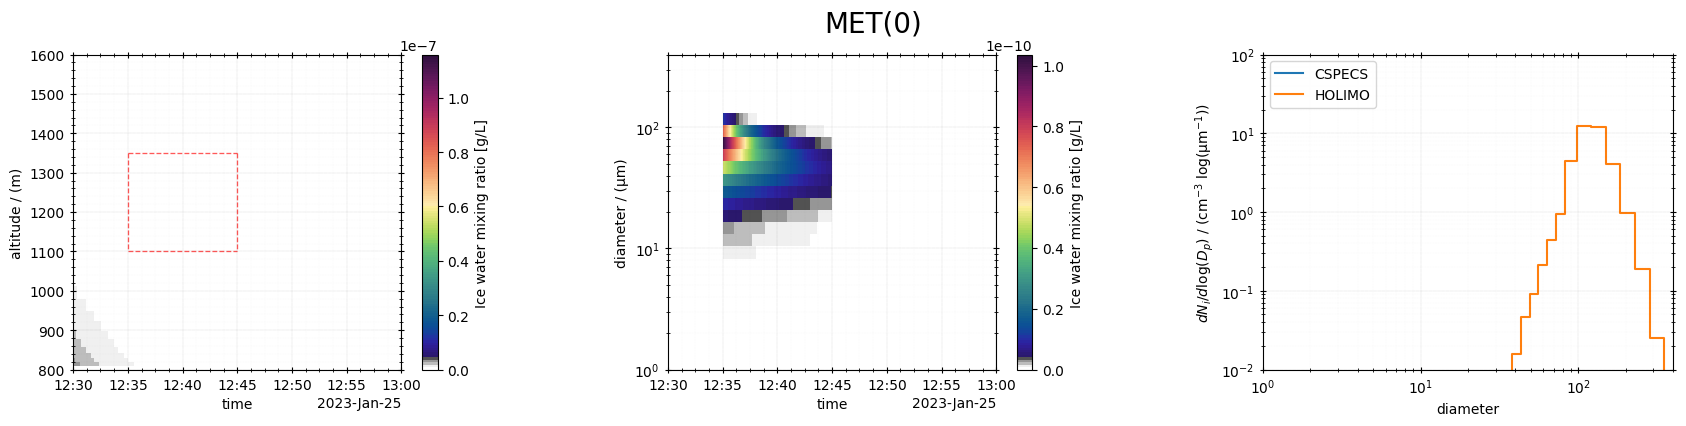

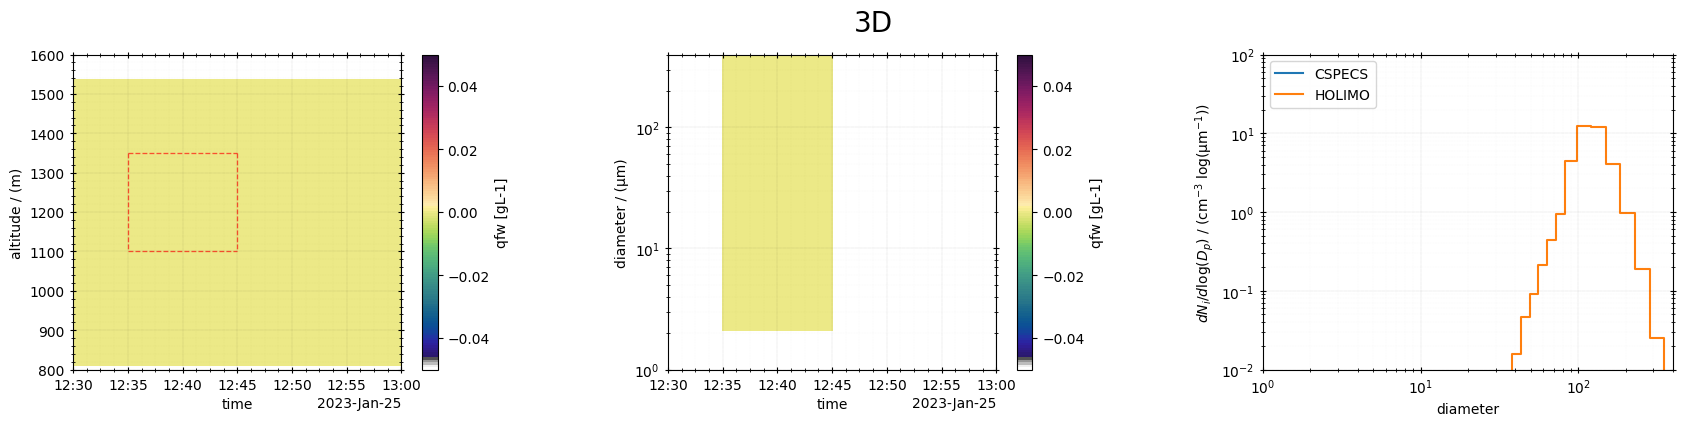

In [12]:
imet = 0
if len(meteo_flist)>0:
    fig_M,  ax_M  = plot_ts_spectra( ds_meteo[imet]['QF'].isel(diameter=slice(30, None)), ds_hd['Ice_PSDnoNorm'], title=f'MET({imet})',
                                     time_window=tw,
                                   )
    
    # fig_M,  ax_M  = plot_ts_spectra( ds_meteo[imet+1]['QFW'].isel(diameter=slice(30, None)), ds_hd['Ice_PSDnoNorm'], title=f'MET({imet+1})',
    #                                  time_window=tw,
    #                                 # time_window=(np.datetime64('2023-01-25T12:28:00'), np.datetime64('2023-01-25T12:38:00'))
    #                                )

fig_3D, ax_3D = plot_ts_spectra( mod['qfw'].isel( diameter=slice(30, None), latitude=imet, longitude=imet ), ds_hd['Ice_PSDnoNorm'], title='3D',
                                # time_window=(np.datetime64('2023-01-25T12:35:00'), 
                                #              np.datetime64('2023-01-25T12:45:00'))
                                # time_window=(np.datetime64('2023-01-25T12:28:00'), 
                                             # np.datetime64('2023-01-25T12:38:00'))
                               )

In [ ]:
ds_3d.sizes

In [ ]:
# # load 3d data into memory, same location as meteograms
# with ProgressBar() as pbar:
#     ds = ds_3d[['qw', 'qfw']].isel( altitude = slice(80, None) )
#     ds = ds.sel( latitude=vcoords[0, :], longitude=vcoords[1, :], method='nearest' )
#     ds = xr.where( ds < 1e-7, np.nan, ds ).persist()



In [13]:
# Plot configuration
cfg = {
    'resolution': '400m' if '50x40' in meta[flare_exp_name]['domain'] else '100m',
    'resolution_deg': 0.004 if '50x40' in meta[flare_exp_name]['domain'] else 0.001,
    'dpi': 300,
    'pixel_size': (1920, 1080),
    'png_path': './QL-TopView/',
    'poolsize': 60,
    'plot_all_frames': True,
    'flare_lat': 47.07425,
    'flare_lon': 7.90522,
    'origin_lat': 47.070522,
    'origin_lon': 7.872991,
    'plot_xlim': (7.7671843, 7.94),
    'plot_ylim': (47.02, 47.12),
    # 'delta_x': 163.3876495361328,
    # 'delta_y': 111.1947021484375,
    # 'delta_t': 10.0,
    'delta_x': float(1e3 * np.mean(np.diff(ds_3d.longitude.values)) * 111.13295254925466),  # 1 degree of longitude in km
    'delta_y': float(1e3 * np.mean(np.diff(ds_3d.latitude.values)) * 111.13295254925466),  # 1 degree of latitude in km
    'delta_t': float(np.mean(np.diff(ds_3d.time.astype('datetime64[s]')).astype(float))),
    'n_lon': 186,
    'n_lat': 146,
    'n_time': 191,
    'vel_lims': [-0.5, 0.5],
    'v_lims_qi': [0.0001, 1.0],
    'tick_size': 8,
    'axis_size': 9.5,
    'timer_size': 16.5
}
cfg

{'resolution': '400m',
 'resolution_deg': 0.004,
 'dpi': 300,
 'pixel_size': (1920, 1080),
 'png_path': './QL-TopView/',
 'poolsize': 60,
 'plot_all_frames': True,
 'flare_lat': 47.07425,
 'flare_lon': 7.90522,
 'origin_lat': 47.070522,
 'origin_lon': 7.872991,
 'plot_xlim': (7.7671843, 7.94),
 'plot_ylim': (47.02, 47.12),
 'delta_x': 653.2584228515625,
 'delta_y': 444.73980712890625,
 'delta_t': 10.0,
 'n_lon': 186,
 'n_lat': 146,
 'n_time': 191,
 'vel_lims': [-0.5, 0.5],
 'v_lims_qi': [0.0001, 1.0],
 'tick_size': 8,
 'axis_size': 9.5,
 'timer_size': 16.5}

In [14]:
ds_3d

<xarray.Dataset> Size: 9GB
Dimensions:      (time: 229, altitude: 20, latitude: 16, longitude: 25,
                  diameter: 66)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2023-01-25T12:28:50 ... 2023-01-25...
  * altitude     (altitude) float64 160B 1.507e+03 1.444e+03 ... 822.0 812.8
  * latitude     (latitude) float32 64B 47.02 47.02 47.03 ... 47.07 47.07 47.08
  * longitude    (longitude) float32 100B 7.767 7.773 7.779 ... 7.902 7.908
  * diameter     (diameter) float64 528B 0.00226 0.002847 ... 7.523e+03
    latitude2D   (latitude, longitude) float32 2kB 47.02 47.02 ... 47.08 47.08
    longitude2D  (latitude, longitude) float32 2kB 7.767 7.773 ... 7.902 7.908
    altitude3D   (altitude, latitude, longitude) float64 64kB dask.array<chunksize=(20, 16, 25), meta=np.ndarray>
Data variables: (12/30)
    t            (time, altitude, latitude, longitude) float64 15MB dask.array<chunksize=(4, 20, 16, 25), meta=np.ndarray>
    p0           (time, altitude, latitude, longitude) float64 15MB dask.array<chunksize=(4, 20, 16, 25), meta=np.ndarray>
    pp           (time, altitude, latitude, longitude) float64 15MB dask.array<chunksize=(4, 20, 16, 25), meta=np.ndarray>
    qv           (time, altitude, latitude, longitude) float64 15MB dask.array<chunksize=(4, 20, 16, 25), meta=np.ndarray>
    rho0         (time, altitude, latitude, longitude) float64 15MB dask.array<chunksize=(4, 20, 16, 25), meta=np.ndarray>
    rho          (time, altitude, latitude, longitude) float64 15MB dask.array<chunksize=(4, 20, 16, 25), meta=np.ndarray>
    ...           ...
    qfa          (time, altitude, latitude, longitude, diameter) float64 967MB dask.array<chunksize=(4, 20, 16, 25, 66), meta=np.ndarray>
    ni           (time, altitude, latitude, longitude) float64 15MB dask.array<chunksize=(4, 20, 16, 25), meta=np.ndarray>
    qia          (time, altitude, latitude, longitude) float64 15MB dask.array<chunksize=(4, 20, 16, 25), meta=np.ndarray>
    vti          (time, altitude, latitude, longitude) float64 15MB dask.array<chunksize=(4, 20, 16, 25), meta=np.ndarray>
    blocks       (time, altitude, latitude, longitude) float64 15MB dask.array<chunksize=(4, 20, 16, 25), meta=np.ndarray>
    weight       (time, altitude, latitude, longitude) float64 15MB dask.array<chunksize=(4, 20, 16, 25), meta=np.ndarray>
Attributes:
    ncfile:   /work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs//...
    run_id:   20260210113944

In [15]:
importlib.reload(utilities)
from utilities import extract_segmented_tracks_fast

reduced_domain = dict(latitude=slice(None,  cfg['flare_lat'] + 2.*cfg['resolution_deg']), 
                      longitude=slice(None, cfg['flare_lon'] + 2.*cfg['resolution_deg']) )
mod2 = ds_3d.isel(altitude=slice(80,None)).sel(reduced_domain)
# load tobac data
tracking_by_var = 'qi+qs'
plot_time_frame = [np.datetime64('2023-01-25T12:00:00'), np.datetime64('2023-01-25T13:00:00')]

tracks = pd.read_csv(f'{model_data_path}/{flare_exp_name}_{tracking_by_var}_tobac_track.csv').to_xarray()
features_mask = pd.read_csv(f'{model_data_path}/{flare_exp_name}_{tracking_by_var}_tobac_features_mask.csv').to_xarray()
ds_segm = xr.open_dataset(f'{model_data_path}/{flare_exp_name}_{tracking_by_var}_tobac_mask_xarray.nc')
ds_segm = ds_segm.sel( time=mod2.time ).sel(reduced_domain)
segmentation = ds_segm['segmentation_mask']
segmentation_mask = segmentation>0.0

nvoxel_min = segmentation.min().values
nvoxel_max = segmentation.max().values
print(f'segmentation.min()/.max() = {nvoxel_min:4d} / {nvoxel_min:10d}' )

# set values outside the plume to nan
cell_input = xr.where( segmentation_mask, mod2[['qw', 'qfw', 'dz', 't']], np.nan )

# two fetch path along plume (time) is independent variable
with ProgressBar() as pbar:
    plume_maxima = extract_segmented_tracks_fast(cell_input,  tracks , **cfg) # maximum of segmented area of plume volumes (1 gridcell)
    plume_integrated = extract_segmented_tracks_fast(cell_input,  tracks, features_mask , **cfg ) # all plume volumes ()

segmentation.min()/.max() =    0 /          0


AlignmentError: cannot align objects with join='exact' where index/labels/sizes are not equal along these coordinates (dimensions): 'altitude' ('altitude',)

NameError: name 'plume_integrated' is not defined

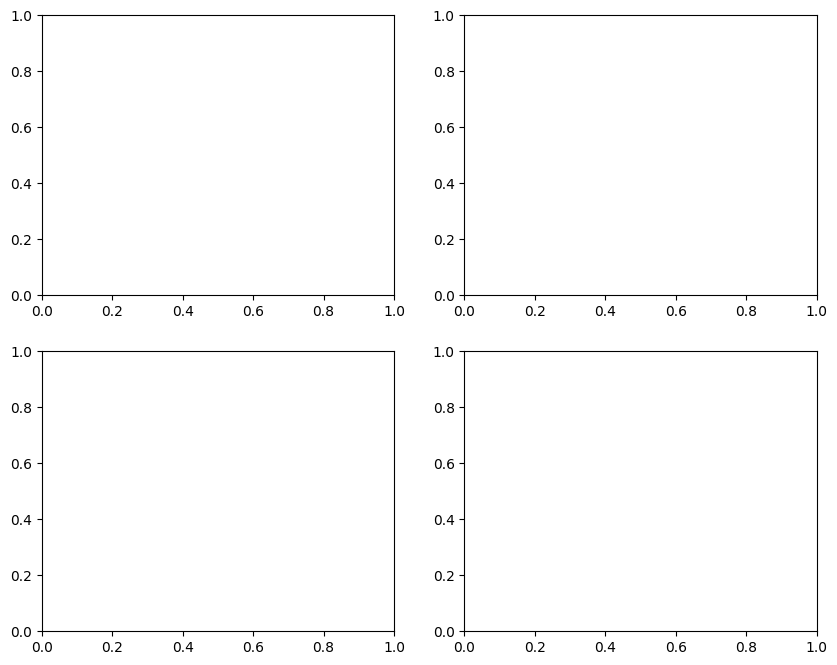

In [16]:
from utilities import new_jet, create_fade_cmap
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

# Format time as MM:SS from start
xr.where(plume_integrated[1]['qw']>0,  plume_integrated[1]['qw'], np.nan).isel( diameter=slice(None, None)).sum('path').plot( ax=ax[0, 0],  x='diameter', xscale='log', yscale='log',   )
xr.where(plume_integrated[1]['qfw']>0, plume_integrated[1]['qfw'], np.nan).isel(diameter=slice(30, None)).sum('path').plot( ax=ax[1, 0],    x='diameter', xscale='log', yscale='log',   )
xr.where(plume_maxima[1]['qw']>0,  plume_maxima[1]['qw'], np.nan).isel( diameter=slice(None, None)).sum('path').plot( ax=ax[0, 1],  x='diameter', xscale='log', yscale='log',   )
xr.where(plume_maxima[1]['qfw']>0, plume_maxima[1]['qfw'], np.nan).isel(diameter=slice(30, None)).sum('path').plot( ax=ax[1, 1],    x='diameter', xscale='log', yscale='log',   )

# for iax in ax.flatten():
#     iax.hlines(plume_integrated[1].diameter.values[30], plume_integrated[1].time.values[0], plume_integrated[1].time.values[-1], linestyle='--', color='black', alpha=0.5)
#     iax.hlines(plume_integrated[1].diameter.values[50], plume_integrated[1].time.values[0], plume_integrated[1].time.values[-1], linestyle='--', color='black', alpha=0.5)

ax[0,0].set_title(r'$\int q_w\d x\, \d y\, \d z$, cloud water content')
ax[0,1].set_title(r'$cell$_{ijk}$ q_w\d x\, \d y\, \d z$, cloud water content')
ax[1,0].set_title(r'$\int q_{i}\d x\, \d y\, \d z$, cloud ice (bins(30-66)) flux')
ax[1,1].set_title(r'$cell$_{ijk}$ q_{i}\d x\, \d y\, \d z$, cloud ice (bins(30-66)) flux')
fig.tight_layout()

In [ ]:
segm_mask['segmentation_mask'].plot()

In [ ]:
cell_qi['qfw'].plot(xscale='log')

In [ ]:
cell_qi